In [1]:
import torch
import numpy as np

In [27]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8) # Input features = 4, hidden layer features = 8
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 3) # Hidden layer features = 8, output features = 3 (for 3 classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

#pick a normal seed for randomization
torch.manual_seed(41)
#Create an instant of model
model = Model()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
url= 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df=pd.read_csv(url)

In [5]:
my_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [15]:
#Train test split! set X, Y
X = my_df.drop('variety', axis=1)
Y = my_df['variety']

In [16]:
# Train test split! set X, Y
X = X.values
Y = Y.values

In [17]:
from sklearn.model_selection import train_test_split

In [19]:
# Train Test split
X_train, X_test, Y_train,Y_test=train_test_split(X,Y,test_size=0.2, random_state=41)

In [20]:
# Convert X features to float tensors
X_train= torch.FloatTensor(X_train)
X_test= torch.FloatTensor(X_test)


In [23]:
from sklearn.preprocessing import LabelEncoder

# Convert y label to tensors long
le = LabelEncoder()
Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)

Y_train= torch.LongTensor(Y_train)
Y_test = torch.LongTensor(Y_test)

In [28]:
import torch.nn as nn
# set the criterion of model to measure the error, how far off the prediction are from
criterion = nn.CrossEntropyLoss()
# choose Ada, optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations)
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [32]:
# Train our model
# Epochs? (one run thru all training data in our network)
epochs = 100
losses = []
for i in range(epochs):
    # Go forward and ge a prediction
    y_pred = model.forward(X_train) # Get prediction result

    # Measure the loss/error, gonna be high at first
    loss = criterion(y_pred, Y_train) # predicted values Vs the  Y_train

    # Keep Track of our losses
    losses.append(loss.detach().numpy())

    # Print every 10 epoch
    if i % 10 == 0:
        print(f'Epoch: {i} Loss: {loss}')


    # Do some back propagation: take the error rate of forward propagation and feed it back
    # thru the network to fine tune the weight
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 Loss: 0.1533602774143219
Epoch: 10 Loss: 0.13245417177677155
Epoch: 20 Loss: 0.11615800112485886
Epoch: 30 Loss: 0.10334960371255875
Epoch: 40 Loss: 0.09315025806427002
Epoch: 50 Loss: 0.08490321785211563
Epoch: 60 Loss: 0.07813026756048203
Epoch: 70 Loss: 0.07248654961585999
Epoch: 80 Loss: 0.06771810352802277
Epoch: 90 Loss: 0.06363753974437714


Text(0.5, 0, 'Epoch')

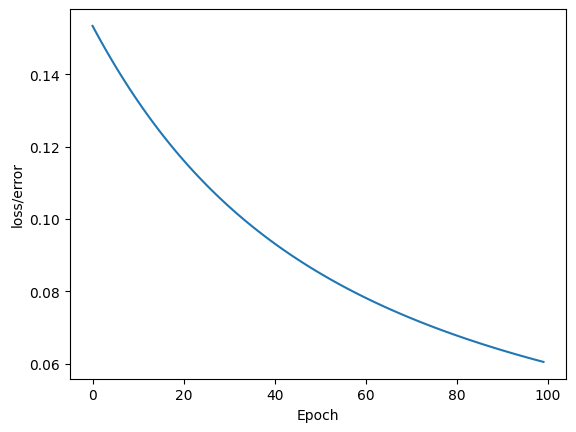

In [33]:
# Graph it out
plt.plot(range(epochs),losses)
plt.ylabel('loss/error')
plt.xlabel('Epoch')